# Scatter plots of stellar extinction

The HEALPix maps can be quite low resolution, but each star has "infinite" spatial resolution. To directly visualize stellar information, we make a scatter plot of extinction, where each point is a star and color corresponds to extinction magnitude. These plots can show finer structures and scan-pattern artifacts. One must be careful when the markers begin to saturate, since close markers are plotted on top of each other instead of averaged.

This notebook makes three such plots:

1. A 10 x 10 degree patch, compared side by side against the binned map of the
   same region
2. The BICEP/Keck CMB field, with the field footprint contour
3. The BICEP/Keck Galactic field, with the field footprint contour


In [1]:
# Autoreload so we don't have to restart the kernel every time we change source code
%load_ext autoreload
%autoreload 2

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
# Astronomy packages
import h5py as h5
import healpy as hp
import astropy.units as u
from astropy.coordinates import SkyCoord
# My packages
# Add src/my_package to the import path (the repo root is one level up)
import sys
_src = os.path.abspath(os.path.join(os.getcwd(), '..', 'src', 'my_package'))
if _src not in sys.path:
    sys.path.insert(0, _src)
import utils
import loader
from constants import data_dir, plt_dir

## 1. Load the catalog, the distance bins, and the fields

In [3]:
"""Initialize a custom loader object for the stellar catalog.
    Rerunning this cell will initialize a new object, removing cached data from memory."""
catalog = loader.StellarCatalogLoader(data_dir + '/xpparams_v2_zenodo')

In [5]:
"""Load the required columns from the Zhang and Green 2025 stellar catalog.
    Requested columns are cached in RAM; only columns not already in cache are read from disk.
    `ext` is the extinction integrated from the observer out to each star."""
ra_all, dec_all, parallax_all, ext_all, quality_flags_all = catalog.get_columns(
    ['ra', 'dec', 'parallax', 'ext', 'quality_flags'])
print(f"{ra_all.size:,} stars in the catalog")

219,197,643 stars in the catalog


In [6]:
"""The 25 distance bins (26 edges, in kpc) used by Zhang and Green 2025.
    Any monotonically increasing array of edges can be used in place of these."""
ZhangGreen = loader.HDF5Loader(data_dir, 'Rv_map_new.h5')
all_distances = ZhangGreen.load_data(['distance_bins'])
print(f"{len(all_distances) - 1} bins, "
      f"{all_distances[0]:.3f} kpc - {all_distances[-1]:.2f} kpc")

Loading ['distance_bins'] from disk into RAM (this happens only once)...
25 bins, 0.000 kpc - 4.93 kpc


In [7]:
"""Initialize objects that represent the CMB and Galactic BICEP/Keck fields."""
cmb = loader.Field('CMB', data_dir)
gal = loader.Field('GAL', data_dir)

Zhang & Green recommend a basic reliability cut of `quality_flags < 8`. Every map
and every scatter plot below applies it.

## 2. Cutting a rectangle out of the catalog

`cut_stellar_params_rectangle` returns the extinction and the sky coordinates of the
stars inside a rectangle, optionally restricted to one distance shell.

Notes:

- The CMB field crosses RA = 0, so the longitude bounds are
  wrapped and the mask changes from `xmin < x AND x < xmax` to
  `x > xmin OR x < xmax` whenever the rectangle crosses the wrap point.
- **`stride`** subsamples the result (`[::stride]`). The Galactic field has enough
  stars to make a scatter plot unreadable and slow; `stride = 10` is a good start.

In [8]:
def cut_stellar_params_rectangle(lon, lat, lonwidth, latwidth, coord,
                                 dist_lims=None, stride=1, quality_max=8,
                                 verbose=True):
    """Stellar extinction and coordinates inside a lonwidth x latwidth rectangle
    centred on (lon, lat), in degrees.

    coord     : 'C' for celestial/ICRS, 'G' for galactic
    dist_lims : (dmin, dmax) in kpc, or None for no distance cut
    stride    : return every `stride`-th star

    Returns (ext, lon, lat), each of the same length."""
    if coord == 'C':
        x, y = ra_all, dec_all
    elif coord == 'G':
        coords = SkyCoord(ra_all * u.degree, dec_all * u.degree, frame='icrs')
        coords = coords.transform_to('galactic')
        x, y = coords.l.degree, coords.b.degree
    else:
        raise ValueError(f"Coordinate system {coord} not supported.")

    # Longitude mask, handling the wrap at 0/360 degrees
    xmin = (lon - lonwidth / 2) % 360
    xmax = (lon + lonwidth / 2) % 360
    if xmin < xmax:
        xmask = (xmin < x) & (x < xmax)
    else:
        xmask = (x > xmin) | (x < xmax)

    # Latitude mask
    ymin = lat - latwidth / 2
    ymax = lat + latwidth / 2
    ymask = (ymin < y) & (y < ymax)

    # Quality cut
    valid = xmask & ymask & (quality_flags_all < quality_max)

    # Optional distance cut
    if dist_lims is not None:
        star_dist = 1 / parallax_all
        valid &= (dist_lims[0] < star_dist) & (star_dist < dist_lims[1])

    if verbose:
        print(f"lon in [{xmin:.2f}, {xmax:.2f}], lat in [{ymin:.2f}, {ymax:.2f}]")
        print(f"{valid.sum():,} stars selected, {valid.sum() // stride:,} after stride")

    return ext_all[valid][::stride], x[valid][::stride], y[valid][::stride]

## 3. A 10 x 10 degree patch

In [9]:
# Patch centre in galactic coordinates, and the distance shell to show.
PATCH_L, PATCH_B = 0, -10
PATCH_WIDTH = 10
patch_bin = 13
patch_lims = all_distances[patch_bin:patch_bin + 2]

ext, l, b = cut_stellar_params_rectangle(PATCH_L, PATCH_B, PATCH_WIDTH, PATCH_WIDTH,
                                         'G', dist_lims=patch_lims, stride=1)

lon in [355.00, 5.00], lat in [-15.00, -5.00]
80,177 stars selected, 80,177 after stride


In [17]:
def scatter_patch(ext, lon, lat, lon0, lat0, width, title,
                  vmin=0, vmax=0.35, save=False, fname=None):
    """Scatter plot of stellar extinction in a small patch, galactic coordinates."""
    hp.mollview(coord='G', title=title, cbar=False, notext=True, hold=True)
    hp.graticule(dpar=2, dmer=2)
    scatter = hp.projscatter(lon, lat, c=ext, s=0.2, cmap='inferno', alpha=1,
                             lonlat=True, vmin=vmin, vmax=vmax)
    ax = plt.gca()
    # mollview axes span x in (-2, 2), y in (-1, 1) for the full sky
    half = width / 2
    ax.set_xlim(-2 * half / 180, 2 * half / 180)
    ax.set_ylim((lat0 - half) / 90, (lat0 + half) / 90)
    ax.set_xticks(2 * np.array([-half, 0, half]) / 180,
                  [f"${lon0 - half:.0f}^\\circ$", f"${lon0:.0f}^\\circ$",
                   f"${lon0 + half:.0f}^\\circ$"])
    ax.set_yticks(np.array([lat0 - half, lat0, lat0 + half]) / 90,
                  [f"${lat0 - half:.0f}^\\circ$", f"${lat0:.0f}^\\circ$",
                   f"${lat0 + half:.0f}^\\circ$"])
    ax.set_xlabel("Galactic longitude", fontsize=10)
    ax.set_ylabel("Galactic latitude", fontsize=10)
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.6)
    cbar.set_label("$E$ [mag]", fontsize=10, labelpad=10)
    if save:
        plt.savefig(os.path.join(plt_dir, fname), bbox_inches='tight')
        plt.close()
    else:
        plt.show()

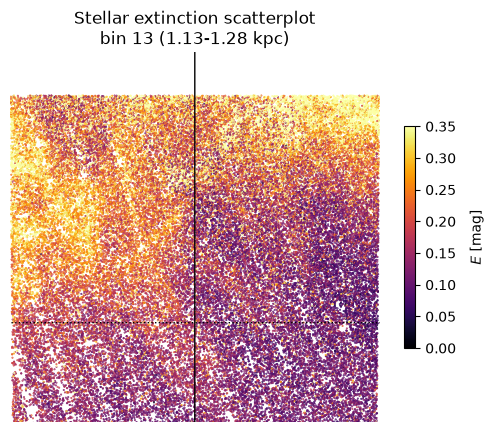

In [18]:
scatter_patch(ext, l, b, PATCH_L, PATCH_B, PATCH_WIDTH,
              f"Stellar extinction scatterplot\nbin {patch_bin} "
              f"({patch_lims[0]:.2f}-{patch_lims[1]:.2f} kpc)")

### The same patch as a binned map

For comparison, the `nside = 1024` map of the same shell, built by
`maps_from_catalog.ipynb` and stored in `my_maps_G_newq.h5`. Only one row of the
dataset is read, so this is cheap despite the file being several GB.

In [13]:
with h5.File(os.path.join(data_dir, 'my_maps_G_newq.h5'), 'r') as f:
    E_map_int_1024_patch = f['E_map/E_map_int_1024'][patch_bin, :]
print(E_map_int_1024_patch.shape)

(12582912,)


In [14]:
def plot_patch_map(ext_map, lon0, lat0, width, title, nest=True,
                   vmin=0, vmax=0.4, save=False, fname=None):
    """The binned counterpart of `scatter_patch`, same projection and limits."""
    hp.mollview(ext_map, coord='G', title=title, nest=nest, xsize=10000,
                cmap='inferno', badcolor='white', min=vmin, max=vmax,
                cbar=False, notext=True, hold=True)
    hp.graticule(dpar=2, dmer=2)
    ax = plt.gca()
    half = width / 2
    ax.set_xlim(-2 * half / 180, 2 * half / 180)
    ax.set_ylim((lat0 - half) / 90, (lat0 + half) / 90)
    ax.set_xlabel("Galactic longitude", fontsize=10)
    ax.set_ylabel("Galactic latitude", fontsize=10)
    im = ax.get_images()[0]
    cbar = plt.colorbar(im, ax=ax, shrink=0.6)
    cbar.set_label("$E$ [mag]", fontsize=10, labelpad=10)
    if save:
        plt.savefig(os.path.join(plt_dir, fname), bbox_inches='tight')
        plt.close()
    else:
        plt.show()

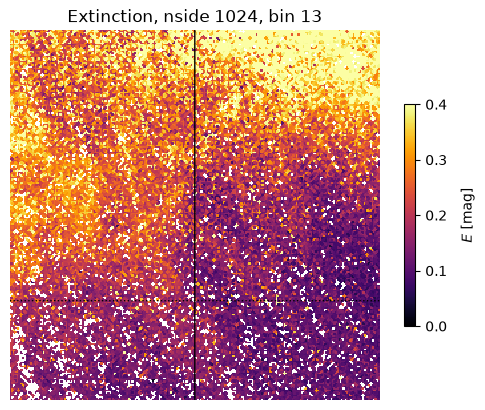

In [15]:
plot_patch_map(E_map_int_1024_patch, PATCH_L, PATCH_B, PATCH_WIDTH,
               f"Extinction, nside 1024, bin {patch_bin}")

## 4. The CMB field

In [21]:
scatter_bin = 13
scatter_lims = all_distances[scatter_bin:scatter_bin + 2]

ra_min, ra_max, dec_min, dec_max = cmb.get_bbox()
cmb_ra_center = (ra_min + ra_max) / 2
cmb_dec_center = (dec_min + dec_max) / 2
# Pad the longitude a little so the footprint is not flush with the edge of the cut
ext_cmb, ra_cmb, dec_cmb = cut_stellar_params_rectangle(
    cmb_ra_center, cmb_dec_center, (ra_max - ra_min) + 10, (dec_max - dec_min),
    'C', dist_lims=scatter_lims, stride=1)

lon in [294.93, 65.07], lat in [-72.97, -38.03]
191,241 stars selected, 191,241 after stride


In [25]:
def scatter_ext_cmb(ext, ra, dec, title, vmin=0, vmax=0.12,
                    contour=True, save=False, fname=None):
    """Scatter plot of stellar extinction in the CMB field, celestial coordinates."""
    ra_min, ra_max, dec_min, dec_max = cmb.get_bbox()
    ra_center = (ra_min + ra_max) / 2
    dec_center = (dec_min + dec_max) / 2
    hp.orthview(coord='C',
                rot=[ra_center, dec_center, 0],
                half_sky=True,
                title=title,
                cbar=False,
                notext=True,
                hold=True)
    # Graticule
    hp.graticule(dpar=10, dmer=25)
    scatter = hp.projscatter(ra, dec, c=ext, s=0.2, cmap='inferno', alpha=0.8,
                             lonlat=True, vmin=vmin, vmax=vmax)

    lon_labels = [50, 25, 0, -25, -50]
    lat_labels = [-70, -60, -50]
    lon0 = 50
    lat0 = -40
    for lon in lon_labels:
        hp.projtext(lon, lat0, f"${lon}^\\circ$", lonlat=True, fontsize=6)
    for lat in lat_labels:
        hp.projtext(lon0, lat, f"${lat}^\\circ$", lonlat=True, fontsize=6)

    # Axes
    ax = plt.gca()
    ax.set_xlim(-0.6, 0.6)
    ax.set_ylim(-0.4, 0.4)
    ax.text(0.0, -0.4 - 0.06, "Right ascension [deg]", fontsize=10,
            va='top', ha='center', color='black')
    ax.text(-0.6 - 0.2, 0.0, "Declination [deg]", fontsize=10, rotation=90,
            va='center', ha='left', color='black')
    # Colorbar
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.5)
    cbar.set_label("$E$ [mag]", fontsize=10, labelpad=10)
    # Field footprint contour
    if contour:
        proj = plt.gca().proj
        xgrid, ygrid = cmb.get_mesh(galactic=False)
        x_contour, y_contour = proj.ang2xy(xgrid.ravel(), ygrid.ravel(), lonlat=True)
        x_contour = x_contour.reshape(xgrid.shape)
        y_contour = y_contour.reshape(ygrid.shape)
        ax.contour(x_contour, y_contour, cmb.Pw, levels = [0.001], colors = 'white')
    # Save or show
    if save:
        plt.savefig(os.path.join(plt_dir, fname), bbox_inches='tight')
        plt.close()
    else:
        plt.show()

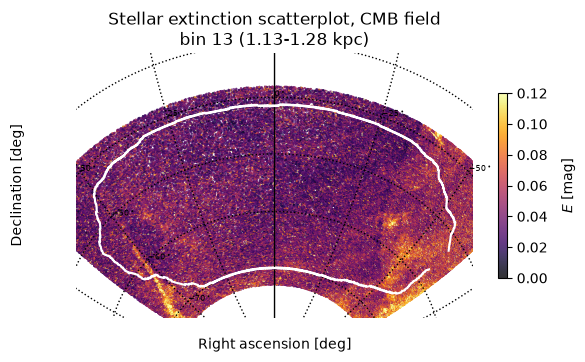

In [26]:
scatter_ext_cmb(ext_cmb, ra_cmb, dec_cmb,
                f"Stellar extinction scatterplot, CMB field\nbin {scatter_bin} "
                f"({patch_lims[0]:.2f}-{patch_lims[1]:.2f} kpc)")

## 5. The Galactic field

The Galactic field has much higher extinction, so `vmax` is an order of
magnitude larger. Because there are so many stars, set `stride = 10`.

In [27]:
ra_min, ra_max, dec_min, dec_max = gal.get_bbox()
gal_ra_center = (ra_min + ra_max) / 2
gal_dec_center = (dec_min + dec_max) / 2
ext_gal, ra_gal, dec_gal = cut_stellar_params_rectangle(
    gal_ra_center, gal_dec_center, (ra_max - ra_min) + 10, (dec_max - dec_min),
    'C', dist_lims=scatter_lims, stride=10)

lon in [175.05, 295.95], lat in [-71.97, -33.03]
1,701,229 stars selected, 170,122 after stride


In [29]:
def scatter_ext_gal(ext, ra, dec, title, vmin=0, vmax=1.8,
                    contour=True, save=False, fname=None):
    """Scatter plot of stellar extinction in the Galactic field, celestial coordinates."""
    ra_min, ra_max, dec_min, dec_max = gal.get_bbox()
    ra_center = (ra_min + ra_max) / 2
    dec_center = (dec_min + dec_max) / 2
    hp.orthview(coord='C',
                rot=[ra_center, dec_center, 0],
                half_sky=True,
                title=title,
                cbar=False,
                notext=True,
                hold=True)
    # Graticule
    hp.graticule(dpar=10, dmer=25)
    scatter = hp.projscatter(ra, dec, c=ext, s=0.2, cmap='inferno', alpha=0.8,
                             lonlat=True, vmin=vmin, vmax=vmax)

    lon_labels = [260, 235, 210, 185]
    lat_labels = [-40, -50, -60, -70]
    lon0 = 285
    lat0 = -40
    for lon in lon_labels:
        hp.projtext(lon, lat0, f"${lon}^\\circ$", lonlat=True, fontsize=6)
    for lat in lat_labels:
        hp.projtext(lon0, lat, f"${lat}^\\circ$", lonlat=True, fontsize=6)

    # Axes
    ax = plt.gca()
    ax.set_xlim(-0.6, 0.6)
    ax.set_ylim(-0.4, 0.4)
    ax.text(0.0, -0.4 - 0.06, "Right ascension [deg]", fontsize=10,
            va='top', ha='center', color='black')
    ax.text(-0.6 - 0.2, 0.0, "Declination [deg]", fontsize=10, rotation=90,
            va='center', ha='left', color='black')
    # Colorbar
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.5)
    cbar.set_label("$E$ [mag]", fontsize=10, labelpad=10)
    # Field footprint contour
    if contour:
        xgrid, ygrid = gal.get_mesh(galactic=False)
        proj = ax.proj
        x_contour, y_contour = proj.ang2xy(xgrid.ravel(), ygrid.ravel(), lonlat=True)
        x_contour = x_contour.reshape(xgrid.shape)
        y_contour = y_contour.reshape(ygrid.shape)
        ax.contour(x_contour, y_contour, gal.Pw, levels = [0.001], colors = 'white')
    # Save or show
    if save:
        plt.savefig(os.path.join(plt_dir, fname), bbox_inches='tight')
        plt.close()
    else:
        plt.show()

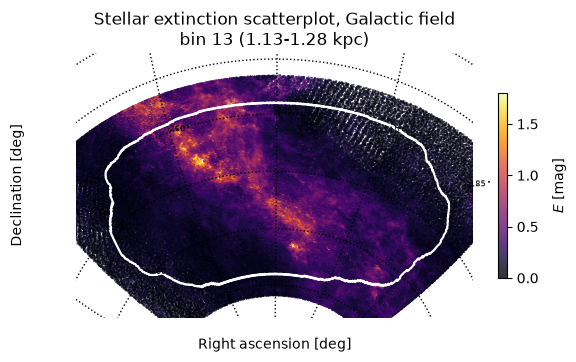

In [31]:
scatter_ext_gal(ext_gal, ra_gal, dec_gal,
                f"Stellar extinction scatterplot, Galactic field\nbin {scatter_bin} "
                f"({patch_lims[0]:.2f}-{patch_lims[1]:.2f} kpc)")